<a href="https://colab.research.google.com/github/he380801-sketch/Prueba/blob/main/regresionlogistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.multiclass import OneVsRestClassifier
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargar datos
df = pd.read_csv('/content/drive/MyDrive/Analisis /IA/2do parcial/DM.csv')

# Ver información básica
print("Información del dataset:")
print(df.info())
print("\nPrimeras filas:")
print(df.head())
print("\nDistribución de grupos:")
print(df['Grupo'].value_counts())

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Grupo         900 non-null    int64  
 1   Participante  900 non-null    object 
 2   Minuto        900 non-null    int64  
 3   C3            900 non-null    float64
 4   C4            900 non-null    float64
 5   CZ            900 non-null    float64
 6   EMG           450 non-null    float64
 7   F3            900 non-null    float64
 8   F4            900 non-null    float64
 9   F7            900 non-null    float64
 10  F8            900 non-null    float64
 11  FP1           900 non-null    float64
 12  FP2           900 non-null    float64
 13  FZ            900 non-null    float64
 14  LOG           900 non-null    float64
 15  O1            900 non-null    float64
 16  O2            900 non-null    float64
 17  P3            900 non-null    float64
 18  P4   

In [ ]:
# Separar características (X) y variable objetivo (y)
X = df.drop(['Grupo', 'Participante'], axis=1)  # Eliminamos Grupo y Participante
y = df['Grupo']

# Codificar la variable objetivo (grupos)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Ver las clases codificadas
print("Clases originales:", label_encoder.classes_)
print("Clases codificadas:", np.unique(y_encoded))

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Escalar las características (importante para regresión logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDimensiones de entrenamiento: {X_train_scaled.shape}")
print(f"Dimensiones de prueba: {X_test_scaled.shape}")

Clases originales: [0 1]
Clases codificadas: [0 1]

Dimensiones de entrenamiento: (720, 23)
Dimensiones de prueba: (180, 23)


In [ ]:
# Crear y entrenar el modelo (One-vs-Rest para multiclase)
logreg = LogisticRegression(
    max_iter=1000,  # Aumentar iteraciones para convergencia
    multi_class='ovr',  # One-vs-Rest
    C=1.0,  # Regularización
    solver='lbfgs'
)

# Handle NaNs in scaled data before training
# Calculate mean of each feature in X_train_scaled, ignoring NaNs
train_means = np.nanmean(X_train_scaled, axis=0)

# Impute NaNs in X_train_scaled with the calculated means
X_train_scaled_imputed = np.where(np.isnan(X_train_scaled), train_means, X_train_scaled)

# Impute NaNs in X_test_scaled with the means calculated from X_train_scaled
X_test_scaled_imputed = np.where(np.isnan(X_test_scaled), train_means, X_test_scaled)


# Entrenar
logreg.fit(X_train_scaled_imputed, y_train)

# Predicciones
y_pred = logreg.predict(X_test_scaled_imputed)
y_pred_proba = logreg.predict_proba(X_test_scaled_imputed)

# Evaluar
print("Accuracy en entrenamiento:", logreg.score(X_train_scaled_imputed, y_train))
print("Accuracy en prueba:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in label_encoder.classes_]))

Accuracy en entrenamiento: 0.8097222222222222
Accuracy en prueba: 0.8111111111111111

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.83      0.72      0.77        80

    accuracy                           0.81       180
   macro avg       0.81      0.80      0.81       180
weighted avg       0.81      0.81      0.81       180



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


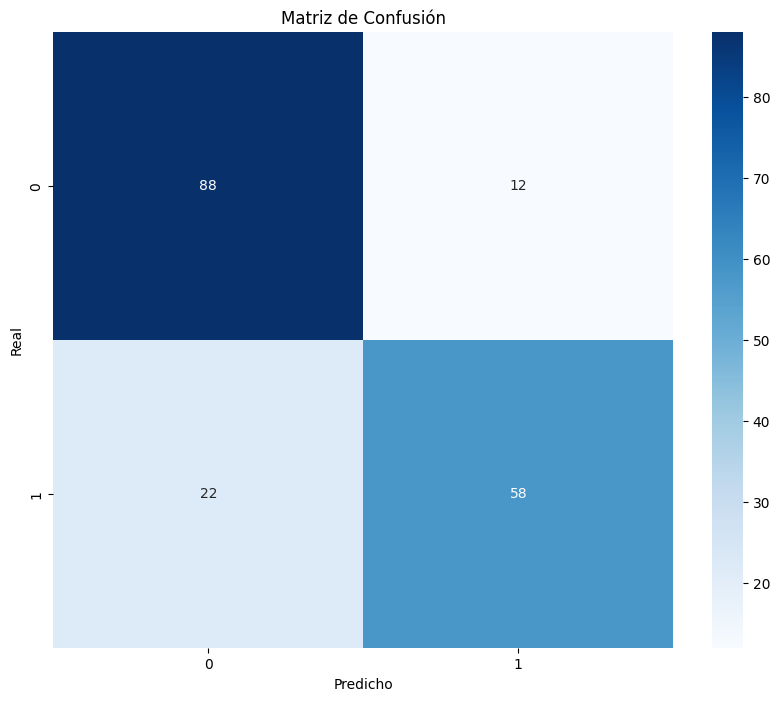

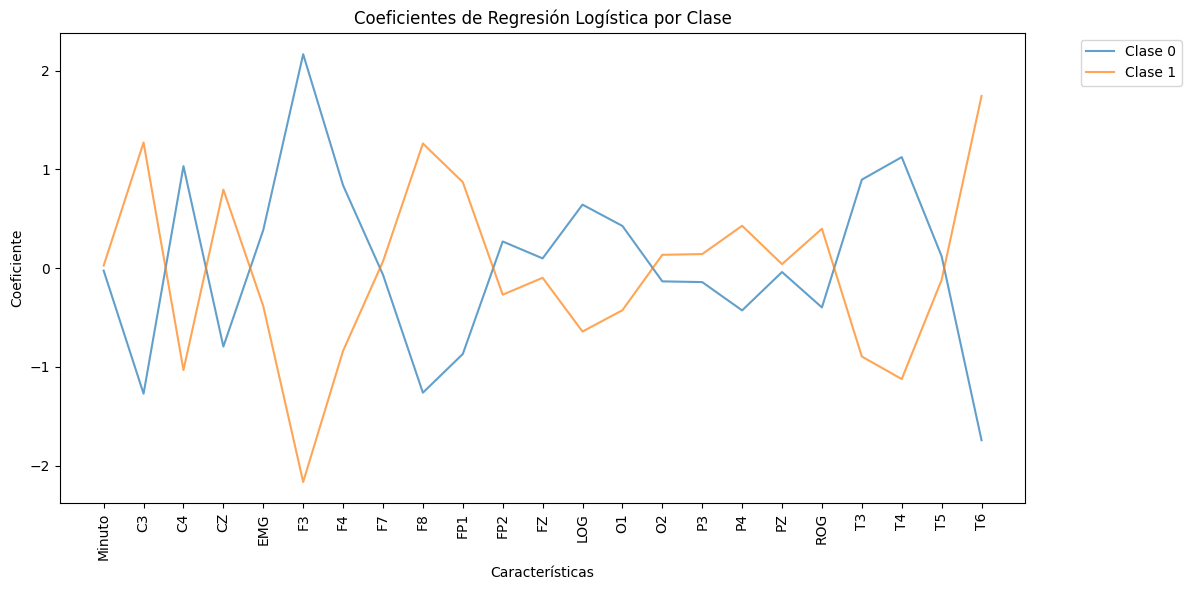

In [ ]:
# Matriz de confusión
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# Importancia de características (coeficientes)
feature_names = X.columns
coefficients = logreg.coef_

plt.figure(figsize=(12, 6))

# Handle binary classification where logreg.coef_ has only one row
if coefficients.shape[0] == 1 and len(label_encoder.classes_) == 2:
    # Coefficients for class 0 are typically the negative of class 1
    plt.plot(feature_names, -coefficients[0], label=f'Clase {label_encoder.classes_[0]}', alpha=0.7)
    plt.plot(feature_names, coefficients[0], label=f'Clase {label_encoder.classes_[1]}', alpha=0.7)
elif coefficients.shape[0] == len(label_encoder.classes_):
    # For multi-class classification where coefficients directly map to each class
    for i, class_name in enumerate(label_encoder.classes_):
        plt.plot(feature_names, coefficients[i], label=f'Clase {class_name}', alpha=0.7)
else:
    print("Unexpected shape for coefficients, cannot plot feature importance per class.")

plt.xlabel('Características')
plt.ylabel('Coeficiente')
plt.title('Coeficientes de Regresión Logística por Clase')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definir parámetros a probar
param_grid = {
    'C': [0.1, 1.0, 10.0, 100.0],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000, 2000]
}

# Grid search
grid_search = GridSearchCV(
    LogisticRegression(multi_class='ovr'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled_imputed, y_train)

# Mejores parámetros
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor accuracy CV:", grid_search.best_score_)

# Evaluar mejor modelo
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled_imputed)
print("Accuracy en prueba con mejor modelo:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report (mejor modelo):")
print(classification_report(y_test, y_pred_best, target_names=[str(c) for c in label_encoder.classes_]))

Mejores parámetros: {'C': 1.0, 'max_iter': 1000, 'solver': 'lbfgs'}
Mejor accuracy CV: 0.7944444444444445
Accuracy en prueba con mejor modelo: 0.8111111111111111

Classification Report (mejor modelo):
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.83      0.72      0.77        80

    accuracy                           0.81       180
   macro avg       0.81      0.80      0.81       180
weighted avg       0.81      0.81      0.81       180



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(




---



In [ ]:
# Predecir probabilidades para un nuevo registro
# Ejemplo: usar el primer registro de prueba
sample = X_test_scaled[0:1]
sample_proba = best_model.predict_proba(sample)

print("Probabilidades para el primer registro de prueba:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name}: {sample_proba[0][i]:.4f}")

print("\nClase predicha:", label_encoder.classes_[best_model.predict(sample)[0]])
print("Clase real:", label_encoder.classes_[y_test[0]])

Probabilidades para el primer registro de prueba:
  0: 0.7422
  1: 0.2578

Clase predicha: 0
Clase real: 1




---



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()

patient_accuracies = []
patient_predictions = []
patient_true = [] # Corrected typo from patien_true to patient_true

all_preds = []
all_true = []

# Define the groups based on the 'Participante' column from the original DataFrame
groups = df['Participante']

# Drop rows with NaN values from X and align y and groups
original_indices = X.index
X = X.dropna()
# Filter y and groups to match the remaining indices in X
y = y.loc[X.index]
groups = groups.loc[X.index]

for train_idx, test_idx in logo.split(X, y, groups):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # -------------------------
    # ESCALADO (CRUCIAL)
    # -------------------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # -------------------------
    # MODELO
    # -------------------------
    model = LogisticRegression(max_iter=1000, class_weight="balanced")
    model.fit(X_train, y_train)

    # Predicciones por cut
    y_pred = model.predict(X_test)

    # -------------------------
    # Patient Accuracy
    # -------------------------
    acc = accuracy_score(y_test, y_pred)
    patient_accuracies.append(acc)

    # -------------------------
    # Majority Vote
    # -------------------------
    majority_pred = np.bincount(y_pred).argmax()
    true_label = y_test.iloc[0]

    patient_predictions.append(majority_pred)
    patient_true.append(true_label)

    # -------------------------
    # Micro Accuracy
    # -------------------------
    all_preds.extend(y_pred)
    all_true.extend(y_test)

In [ ]:
mean_acc = np.mean(patient_accuracies)
std_acc = np.std(patient_accuracies)

patient_level_acc = accuracy_score(patient_true, patient_predictions)

cm = confusion_matrix(patient_true, patient_predictions)

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

micro_acc = accuracy_score(all_true, all_preds)

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

avg_prob = np.mean(y_prob)

# threshold 0.5
prob_pred = 1 if avg_prob >= 0.5 else 0

In [ ]:
feature_names = X.columns
coefficients = model.coef_[0]

for name, coef in zip(feature_names, coefficients):
    print(name, coef)

Minuto -0.09564803530216141
C3 -0.4707504478604661
C4 -1.0970775433845439
CZ 0.5987193937081242
EMG -0.3240979939569699
F3 -1.482837421284113
F4 -0.2179320374233826
F7 -0.1175758924400487
F8 0.6923809092207075
FP1 0.44722568892329756
FP2 -1.2264108262846212
FZ 0.9710518335007663
LOG -0.41221055040684235
O1 -1.0723530766463147
O2 -0.6897308189174082
P3 0.5655867863539097
P4 1.0509294415533668
PZ -0.3236948385716396
ROG 0.14285689599211504
T3 -1.1144127400091859
T4 -0.6525253370480372
T5 1.0267614540218226
T6 1.8000437622627345
